In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## EDA

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")

In [3]:
df.info()    # Общая информация и типы
df.describe() # Статистика по данным, среднее, максимальное, минимальное
df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isna().sum() # считаем сколько пропусков в калонках
df = df.dropna(subset=['Age'])
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000
mean,448.582633,0.406162,2.236695,29.699118,0.512605,0.431373,34.694514
std,259.119524,0.491460,0.838250,14.526497,0.929783,0.853289,52.918930
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.250000,0.000000,1.000000,20.125000,0.000000,0.000000,8.050000
50%,445.000000,0.000000,2.000000,28.000000,0.000000,0.000000,15.741700
75%,677.750000,1.000000,3.000000,38.000000,1.000000,1.000000,33.375000
max,891.000000,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


<Axes: xlabel='Survived', ylabel='count'>

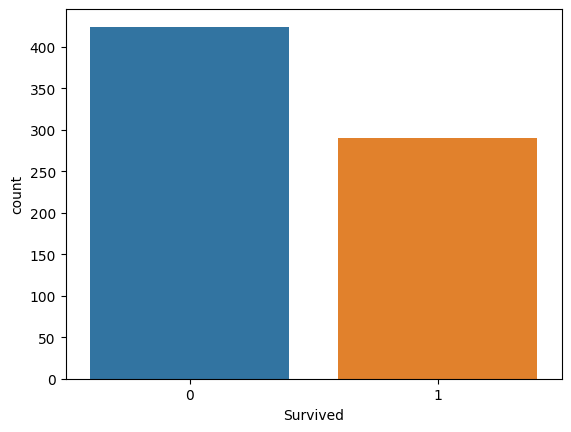

In [5]:
not_survived_ = df[df['Survived'] == 0]
survived_ = df[df['Survived'] == 1]
sns.countplot(x='Survived', data=not_survived_) # выводим даные о смертях в виде графика
sns.countplot(x='Survived', data=survived_) # выводим даные о выживших в виде график

<Axes: xlabel='Survived', ylabel='count'>

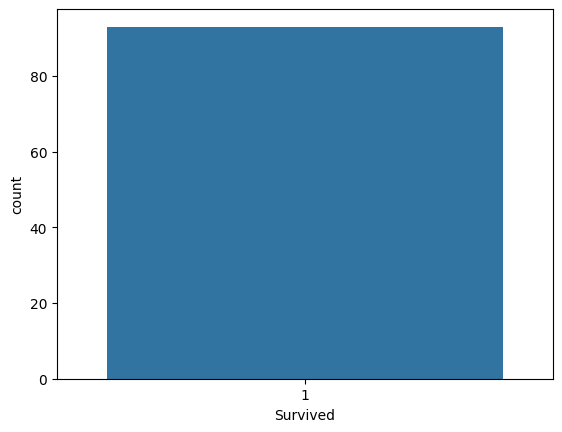

In [6]:
male_survived_ = df[(df['Survived'] == 1) & (df["Sex"] == "male")]
sns.countplot(x='Survived', data=male_survived_) # выводим даные о смертях мужчинах в виде графика

<Axes: xlabel='Survived', ylabel='count'>

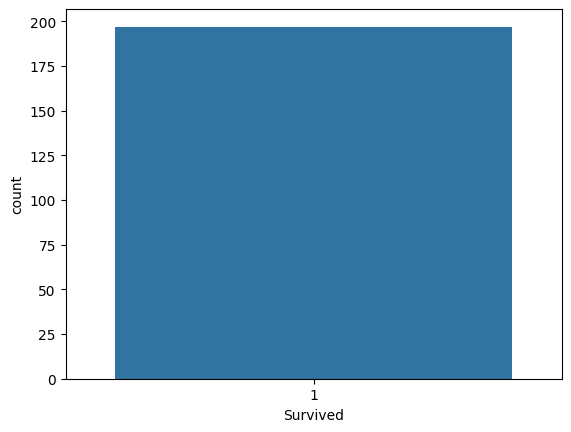

In [7]:
female_survived_ = df[(df['Survived'] == 1) & (df["Sex"] == "female")]
sns.countplot(x='Survived', data=female_survived_) # выводим даные о выживших женщинах в виде график

<Axes: >

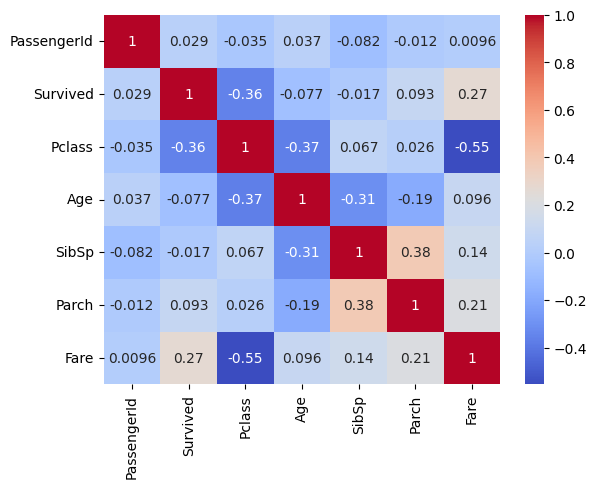

In [8]:
# Посчитать корреляцию только для числовых данных
corr_matrix = df.corr(numeric_only=True) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')


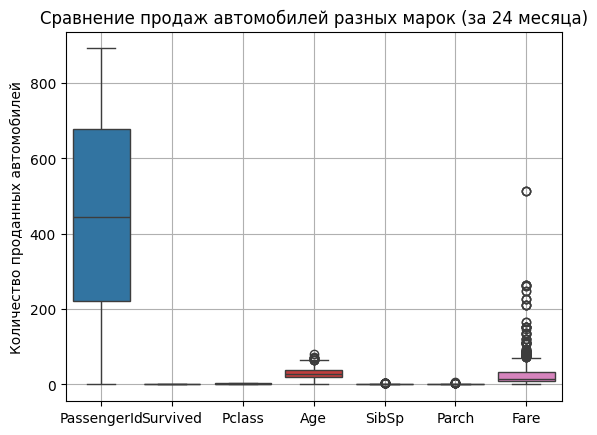

In [9]:
# строим boxplot для нахождения выбросов
sns.boxplot(data=df)
plt.title("Сравнение продаж автомобилей разных марок (за 24 месяца)")
plt.ylabel("Количество проданных автомобилей")
plt.grid(True)
plt.show()

## Data optimization

In [10]:
# фильтруем данные от выбросов
df = df[df["Fare"] <= 200]

## Creat Model

In [11]:
# создаем целевые переменные X и y
X = df[["Survived", "Parch", "Pclass"]] 
y = df["Fare"]

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
ridge_model = Ridge(alpha=1.0) 
ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
score = ridge_model.score(X_test, y_test)

print(f"Ridge Score: {score:.4f}")
print(f"Ridge MSE: {mse:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")
print(f"Веса Ridge: {ridge_model.coef_}")

Ridge Score: 0.4599
Ridge MSE: 526.63
RMSE: 22.95
Веса Ridge: [  0.93175676   7.55639143 -20.8054448 ]


In [13]:
# создаем и обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [14]:
# получаем результат обучения
weight = model.coef_
bias = model.intercept_
score = model.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Вес для Survived (w1): {weight[0]:.2f}")
print(f"Вес для Parch (w2): {weight[1]:.2f}")
print(f"Вес для Pclass (w3): {weight[2]:.2f}")
print(f"Смещение (b): {bias:.2f}")
print(f"MSE {mse}")# 1)2678.832072553141 2)2595.3529653904557 3)2503.8569343678946
print(f"RMSE: {np.sqrt(mse):.2f}")
print(f"score {score}") # 1)score 0.07192513422104585 2)0.042073756698027265 3)0.10464329157495145

Вес для Survived (w1): 0.91
Вес для Parch (w2): 7.58
Вес для Pclass (w3): -20.85
Смещение (b): 27.44
MSE 526.7478726557448
RMSE: 22.95
score 0.4597611742366904


D:\Python project\Project\interns_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


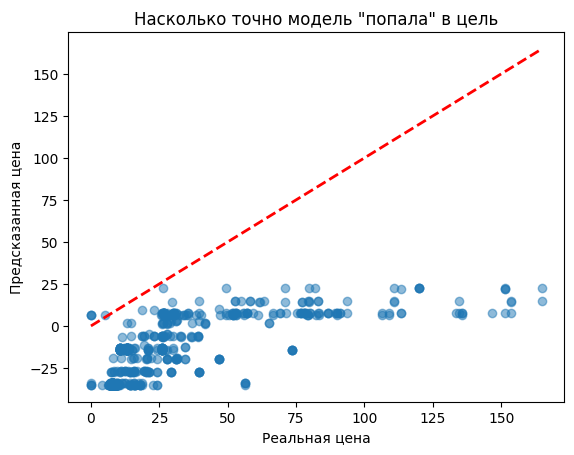

In [15]:
# Визуализация
plt.scatter(y, model.predict(X), alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Линия идеального предсказания
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Насколько точно модель "попала" в цель')
plt.show()